In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from copy import deepcopy
from brain2behaviour.dataset import BrainBehaviorDataset
from brain2behaviour.preprocessing import clean_fold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from brain2behaviour.preprocessing import clean_fold,BrainPipeline,BehPipeline
from brain2behaviour.Linear.CPM_classic import sum_features4CPM

## File loading for generalization
Generalization uses instantiations of the helper brain2behaviour package's dataset class. 

These data package together one of parcel surface area, cortical distance, or functional connectivity data hosted here: https://zenodo.org/records/20529526

With the behavioural prediction target (Oral Reading Recognition) and their confounds. 

However, as the confounds contain restricted data from both the HCP YA cohort and Lifesapn HCP Aging cohorts users must reinstantiate these instances themselves. 

To do this, follow the tutorial in notebook 1 of how to instantiate a dataset class. 

Do note, that features can be set as shown in the following cell, ensuring that if reinstantiated according to the instrictions, our results can be replicated. Features selected are shared as our the results from the cross-validaton analysis

-- a general note -- subjects with age 100 are excluded as this was also and indicator of missing data

In [ ]:
### function to load preselected stable features from cross-validation 
import json
def load_dict_from_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:

##################### Distance #################### 
hcp_edu_dist=BrainBehaviorDataset.load('<path_to_Distance_HCP_YA.pkl>')
featsEdu_dist=load_dict_from_json(f'./data/results/Reading_SES_DistanceCentroid_cpm_analysis/ds_permed0000_stable.json')
### we can share the features extracted -- it should always be stable 0 as number corresponds to permutation. 0th is non permuted. 
hcp_edu_aged_dist=BrainBehaviorDataset.load('<path_to_Distance_HCP_A.pkl>')

### we drop participants who's age is marked as 100 as this was the default value for no value
age100=hcp_edu_aged_dist.confounds['Age_in_Yrs'][hcp_edu_aged_dist.confounds['Age_in_Yrs']==100].index
hcp_edu_aged_dist.confounds=hcp_edu_aged_dist.confounds.drop(index=age100)
hcp_edu_aged_dist.brainData=hcp_edu_aged_dist.brainData.drop(index=age100)
hcp_edu_aged_dist.behaviorData=hcp_edu_aged_dist.behaviorData.drop(index=age100)
hcp_edu_aged_dist.indices=hcp_edu_aged_dist.confounds.index

# ########################## FC ################ 
hcp_edu_fc=BrainBehaviorDataset.load('<path_to_FC_HCP_YA.pkl>')
featsEdu_fc=load_dict_from_json(f'./data/results/Reading_SES_FC_cpm_analysis/ds_permed0000_stable.json')
hcp_edu_aged_fc=BrainBehaviorDataset.load(f'<path_to_FC_HCP_A.pkl')

age100=hcp_edu_aged_fc.confounds['Age_in_Yrs'][hcp_edu_aged_fc.confounds['Age_in_Yrs']==100].index
hcp_edu_aged_fc.confounds=hcp_edu_aged_fc.confounds.drop(index=age100)
hcp_edu_aged_fc.brainData=hcp_edu_aged_fc.brainData.drop(index=age100)
hcp_edu_aged_fc.behaviorData=hcp_edu_aged_fc.behaviorData.drop(index=age100)
hcp_edu_aged_fc.indices=hcp_edu_aged_fc.confounds.index

# # ###################### Surface area #########
hcp_edu_sa=BrainBehaviorDataset.load('<path_to_FC_HCP_YA.pkl>')
featsEdu_sa=load_dict_from_json(f'./data/results/Reading_SES_SurfaceArea_cpm_analysis/ds_permed0000_stable.json')
hcp_edu_aged_sa=BrainBehaviorDataset.load('<path_to_FC_HCP_A.pkl>')

age100=hcp_edu_aged_sa.confounds['Age_in_Yrs'][hcp_edu_aged_sa.confounds['Age_in_Yrs']==100].index
hcp_edu_aged_sa.confounds=hcp_edu_aged_sa.confounds.drop(index=age100)
hcp_edu_aged_sa.brainData=hcp_edu_aged_sa.brainData.drop(index=age100)
hcp_edu_aged_sa.behaviorData=hcp_edu_aged_sa.behaviorData.drop(index=age100)
hcp_edu_aged_sa.indices=hcp_edu_aged_sa.confounds.index


### Generalization set up functions

## Data cleaning for cross-cohort generalization

Builds matched train/test design matrices by residualizing brain and behavior
data against shared confounds. `ds_ref` provides the training rows; `ds_new`
provides the test rows. The two are concatenated into a composite dataset so
that confound cleaning is **fit on training subjects and applied to test
subjects** — avoiding leakage from the validation cohort.

In our analysis, `ds_ref` is always the **HCP Young Adult** discovery cohort.
Confound relationships are learned there and applied to the **HCP Aging**
(Lifespan) validation cohort.

**Steps**
1. If `'Acquisition'` is in `ds_ref.confounds` but not `ds_new.confounds`, a
   dummy `'Acquisition' = 'Q11'` is added to `ds_new`.
2. Brain features are summed via `sum_features4CPM`.
3. `clean_fold` handles encoding, gaussianization, z-scoring, and head-size PCA.
4. `BrainPipeline` and `BehPipeline(gaussianize=True)` residualize both sides,
   fit on train and applied to test.

**Parameters**
- `ds_ref`, `ds_new` — Datasets exposing `brainData`, `behaviorData`,
  `confounds`, `indices`, `features`, and `cv_folds`.
- `feat_dict` — Feature dict applied to both sides before cleaning.
- `encode_cols` — Confound columns to encode in `clean_fold`.
- `passthrough_cols` — Confound columns to leave untouched.
- `partial` — Optional list of confound names to hold out of residualization
  and re-attach to the output (for partial correlation). If `None`, all
  confounds are regressed out.

**Returns**
- `model_df_train`, `model_df_test` — Residualized brain + behavior, with
  held-out `partial` confounds appended when provided.

In [5]:
def apply_transforms(ds_ref,ds_new,feat_dict,encode_cols,passthrough_cols,partial=None):    
    if 'Acquisition' in ds_ref.confounds.columns and 'Acquisition' not in ds_new.confounds.columns:
        print('adding acquisition dummy variable to test dataset')

        ds_new.confounds['Acquisition']='Q11'

    gen_Train=deepcopy(ds_ref)
    gen_Train.features=feat_dict
    all_subs_train=ds_ref.indices
     
    gen_Test=deepcopy(ds_new)
    
   
    gen_Test.features=feat_dict
    
    all_subs_test=ds_new.indices
    drop_subs=list(ds_new.confounds['Age_in_Yrs'][ds_new.confounds['Age_in_Yrs']==100].index)
    # all_subs_test = [s for s in ds_new.indices if s not in drop_subs]

    composite_ds=deepcopy(ds_ref)
    composite_ds.brainData=pd.concat([gen_Train.brainData,gen_Test.brainData])
    composite_ds.behaviorData=pd.concat([gen_Train.behaviorData,gen_Test.behaviorData])
    composite_ds.confounds=pd.concat([gen_Train.confounds,gen_Test.confounds])
    composite_ds.features=feat_dict
    composite_ds.cv_folds['all']={'training':all_subs_train,'testing':all_subs_test}
    train_idx=composite_ds.cv_folds['all']['training']
    test_idx=composite_ds.cv_folds['all']['testing']

    composite_ds.brainData=sum_features4CPM(composite_ds)

    cleaned_data=clean_fold(composite_ds, 'all',
                    encode_cols=encode_cols,
                    area_cols=("Larea", "Rarea"),
                    volume_cols=("FS_IntraCranial_Vol", "FS_BrainSeg_Vol"),
                    bin_encode={"Acquisition": 2},
                    passthrough_cols=passthrough_cols,
                    gaussianize=True,
                    add_squares=True,
                    zscore_cols=True,
                    pca_head_size=True)
    if partial is None:
        brain_pipe = BrainPipeline()
        beh_pipe = BehPipeline(gaussianize=True)
        train_confs=cleaned_data['train_confounds']
        test_confs=cleaned_data['test_confounds']
        brain_train_clean = brain_pipe.fit_transform(composite_ds.brainData.loc[train_idx], train_confs)
        beh_train_clean = beh_pipe.fit_transform(composite_ds.behaviorData.loc[train_idx], train_confs)
    
        brain_test_clean  = brain_pipe.transform(composite_ds.brainData.loc[test_idx],  test_confs)
        beh_test_clean  = beh_pipe.transform(composite_ds.behaviorData.loc[test_idx],  test_confs)

        
        print('do it with residualized data')
        model_df_train=pd.concat([brain_train_clean,beh_train_clean],axis=1)

        model_df_test=pd.concat([brain_test_clean,beh_test_clean],axis=1)
        return model_df_train,model_df_test
    else:
        if isinstance(partial,list):
            part_cors=partial
        else:
            print("Error: 'partial' must be a list.")
            return  # exits the function
    conf_part=[]
    for i in part_cors:
        conf_part.append(pd.concat([cleaned_data['train_confounds'][[i]],cleaned_data['test_confounds'][[i]]]))
    print(f'calculating partial correlation with respect to {part_cors}')

    conf_part=pd.concat(conf_part,axis=1)
    train_confs=cleaned_data['train_confounds'].drop(columns=part_cors)
    test_confs=cleaned_data['test_confounds'].drop(columns=part_cors)

     ### pipe the confounds into the residualization transformers
    brain_pipe = BrainPipeline()
    beh_pipe = BehPipeline(gaussianize=True)
    ### fit and residualize training
    print(f'residualizing both sides with {train_confs.columns}')
    brain_train_clean = brain_pipe.fit_transform(composite_ds.brainData.loc[train_idx], train_confs)
    beh_train_clean = beh_pipe.fit_transform(composite_ds.behaviorData.loc[train_idx], train_confs)

    brain_test_clean  = brain_pipe.transform(composite_ds.brainData.loc[test_idx],  test_confs)
    beh_test_clean  = beh_pipe.transform(composite_ds.behaviorData.loc[test_idx],  test_confs)

    model_df_train=pd.concat([brain_train_clean,beh_train_clean,conf_part.loc[train_idx]],axis=1)

    model_df_test=pd.concat([brain_test_clean,beh_test_clean,conf_part.loc[test_idx]],axis=1)

    return model_df_train,model_df_test


In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import seaborn as sns, matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],  # fallback-safe, always available
    "pdf.fonttype": 42,   # embed fonts properly in PDF
    "ps.fonttype": 42})

Stats functions
1. Generate a set of permutations
2. Permutation test function 
3. Bootstrap Confidence Interval function

In [12]:
### Functions which calculate the p value of the observed generalized stat and the confidence interval of it
def get_test_perms(data,n_perm,seed=42):
    """Generate `n_perm` row-index permutations of `data` for permutation testing."""
    rng = np.random.default_rng(seed=seed)
    n=data.shape[0]
    perm_indices = np.array([rng.permutation(n) for _ in range(n_perm)])
    return perm_indices

def perm_predictions(pred, y_true,perm_indices,ci=0.95):
    """Observed r/RMSE/MAE with permutation p-values and bootstrap CIs, returned as a one-row DataFrame."""
    pred=pred.ravel()
    y_true=y_true.ravel()
    ### pearson observed
    r_obs= np.corrcoef(pred, y_true)[0][1]
    ### rmse observed
    rmse_obs = mean_squared_error(y_true, pred, squared=False)
    mae_obs = mean_absolute_error(y_true, pred)

    ### calculate confidence intervals
    ci_dict=bootstrap_ci_prediction(pred,y_true,interval=ci)
    
    perm_r=[np.corrcoef(pred,y_true[i])[0][1] for i in perm_indices]
    perm_rmse=[mean_squared_error(pred,y_true[i],squared=False) for i in perm_indices]
    perm_mae=[mean_absolute_error(pred,y_true[i]) for i in perm_indices]
    
    p_perm_pearson = (np.sum(np.abs(perm_r) >= np.abs(r_obs)) + 1) / (len(perm_indices) + 1)

    p_perm_rmse = (np.sum(perm_rmse <= rmse_obs) + 1) / (len(perm_indices) + 1)
    p_perm_mae = (np.sum(perm_mae <= mae_obs) + 1) / (len(perm_indices) + 1)

    out=pd.DataFrame([{'r':r_obs,'r_p':p_perm_pearson,'r_low':ci_dict['r_ci'][0],'r_hi':ci_dict['r_ci'][1],
    'rmse':rmse_obs,'rmse_p':p_perm_rmse,'rmse_low':ci_dict['rmse_ci'][0],'rmse_hi':ci_dict['rmse_ci'][1],
    'mae':mae_obs,'mae_p':p_perm_mae,'mae_low':ci_dict['mae_ci'][0],'mae_hi':ci_dict['mae_ci'][1]}])
  
    return out


def bootstrap_ci_prediction(pred, true, n_boot=10_000, seed=42,interval=0.95):
    """Bootstrap confidence intervals for Pearson r, RMSE, and MAE between `pred` and `true`."""
    pred = pred.ravel()
    true = true.ravel()
    n = len(pred)

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, (n_boot, n))
    r_boot=[np.corrcoef(pred[i], true[i])[0,1] for i in idx]
    rmse_boot=[mean_squared_error(pred[i], true[i],squared=False) for i in idx]
    mae_boot=[mean_absolute_error(pred[i], true[i]) for i in idx]

    alpha = (1 - interval) / 2
    lo, hi = 100 * alpha, 100 * (1 - alpha)
    
    return {'r_ci': np.percentile(r_boot, [lo, hi]),'rmse_ci': np.percentile(rmse_boot, [lo, hi]),
        'mae_ci': np.percentile(mae_boot, [lo, hi])}

Cross-cohort generalization
1. Within cohort residualizaton helper function (handles age)
2.  general test of prediction generalizatoin to an external cohort

In [ ]:
def residualize_within_cohort(X, age):
    """Regress `age` out of `X` within a single cohort.

    Used for confounds that can't be estimated from the training cohort alone.
    In our analysis this was age, since HCP-YA spans 22-35 and HCP-A spans
    36-100 with no overlap — a harmonization decision.
    """
    lr = LinearRegression().fit(age, X)
    Xr=X - lr.predict(age)
    return Xr


def test_prediction_generalization(train_df,test_df,counfound_cols:list,n_perms:int,resid=True):
    """Fit Positive/Negative/Joint CPM models on `train_df`, predict ReadEng_Unadj on
    `test_df`, and return permutation-tested metrics plus the predictions.

    If `resid=True`, the positive and negative network strengths are residualized
    within each cohort against `counfound_cols` before fitting. In or analysis we do this for age terms.
    """
    train_df=train_df.copy()
    test_df=test_df.copy()
   
    results={}
    y_train=train_df['ReadEng_Unadj']
    y_test=test_df['ReadEng_Unadj'].ravel()

    predictions={}
    if resid==True:
        train_df[['positive','negative']]=residualize_within_cohort(train_df[['positive', 'negative']],train_df[counfound_cols])
        test_df[['positive','negative']]=residualize_within_cohort(test_df[['positive', 'negative']],test_df[counfound_cols])
    second_feats={'Positive':'positive','Negative':'negative','Joint':['positive','negative']}
    for key in second_feats:
        x_train=pd.DataFrame(train_df[second_feats[key]])
        x_test=pd.DataFrame(test_df[second_feats[key]])
        lr=LinearRegression()
        lr.fit(x_train,y_train)
        pred=lr.predict(x_test).ravel()
        predictions[key]=pred
    
        #### generate the permutatoin set 
    perm_indices=get_test_perms(test_df,n_perms,seed=42)
    results={}  
    
    for key in predictions:
        pg.corr(predictions[key].ravel(),y_test.ravel())

        results[key]=perm_predictions(predictions[key],y_test,perm_indices)

    predictions['true']=y_test
    results=pd.concat(results, axis=0).droplevel(1)
    return results,predictions

Result handling

1. Compile the results of an analysis for a single modality run

In [10]:
def recompile_r_vals_single_modality(df1, df2, df3):
    """Compile the results of an analysis for a single modality run"""
    df_r = pd.DataFrame({
        "Positive": [df1.loc["Positive", "r"], df2.loc["Positive", "r"], df3.loc["Positive", "r"]],
        "Negative": [df1.loc["Negative", "r"], df2.loc["Negative", "r"], df3.loc["Negative", "r"]],
        "Joint":    [df1.loc["Joint", "r"],    df2.loc["Joint", "r"],    df3.loc["Joint", "r"]],
    }, index=["SA", "CD", "FC"])


    df_r_lo = pd.DataFrame({
        "Positive": [df1.loc["Positive", "r_low"], df2.loc["Positive", "r_low"], df3.loc["Positive", "r_low"]],
        "Negative": [df1.loc["Negative", "r_low"], df2.loc["Negative", "r_low"], df3.loc["Negative", "r_low"]],
        "Joint":    [df1.loc["Joint", "r_low"],    df2.loc["Joint", "r_low"],    df3.loc["Joint", "r_low"]],
    }, index=["SA", "CD", "FC"])

    df_r_hi = pd.DataFrame({
        "Positive": [df1.loc["Positive", "r_hi"], df2.loc["Positive", "r_hi"], df3.loc["Positive", "r_hi"]],
        "Negative": [df1.loc["Negative", "r_hi"], df2.loc["Negative", "r_hi"], df3.loc["Negative", "r_hi"]],
        "Joint":    [df1.loc["Joint", "r_hi"],    df2.loc["Joint", "r_hi"],    df3.loc["Joint", "r_hi"]],
    }, index=["SA", "CD", "FC"])


    df_r_p = pd.DataFrame({
        "Positive": [df1.loc["Positive", "r_p"], df2.loc["Positive", "r_p"], df3.loc["Positive", "r_p"]],
        "Negative": [df1.loc["Negative", "r_p"], df2.loc["Negative", "r_p"], df3.loc["Negative", "r_p"]],
        "Joint":    [df1.loc["Joint", "r_p"],    df2.loc["Joint", "r_p"],    df3.loc["Joint", "r_p"]],
    }, index=["SA", "CD", "FC"])
    
    
    return df_r,df_r_lo,df_r_hi,df_r_p



## Plotting functions used for figure 2

Plotting functions... no really that's all
1. Pointplot code for non unimodal models
2. Pointplot code for multimodal models

In [13]:

def pointplot_ci(df, sign, df_p, df_lo, df_hi, lo, hi, palette,
                 w=30, h=30, labelticks=True, opath=None):

    mm = 1 / 25.4
    plt.rcParams.update({
        "figure.figsize": (w * mm, h * mm),
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.linewidth": 0.3,
        "svg.fonttype": "none",
    })

    fig, ax = plt.subplots()

    # >>> CONTROL HORIZONTAL SPACING HERE <<<
    dx = 0.6            # smaller = closer together
    x = np.arange(len(df)) * dx + 1

    pad = max((hi - lo) * 0.12, 0.07)
    ax.set_ylim(lo - pad, hi + pad)

    for xi, lbl in zip(x, df.index):
        m = df.loc[lbl, sign]
        yerr = [[m - df_lo.loc[lbl, sign]],
                [df_hi.loc[lbl, sign] - m]]

        print(
            f"{lbl}: r={df.loc[lbl, sign]:.4f} "
            f"[{df_lo.loc[lbl, sign]:.4f}, {df_hi.loc[lbl, sign]:.4f}], "
            f"p={df_p.loc[lbl, sign]:.4f}"
        )

        c = palette[lbl]
        ax.errorbar(
            xi, m, yerr=yerr, fmt='none',
            ecolor=c, elinewidth=1.6,
            capsize=0, capthick=0, zorder=2
        )
        ax.scatter(
            xi, m, s=36, marker='_',
            color=c, linewidths=1.6, zorder=4
        )

    if labelticks:
        ax.tick_params(axis='both', which='major',
                       labelsize=7, length=2, width=0.3,
                       bottom=True, left=True)
    else:
        ax.tick_params(axis='both', which='major',
                       labelsize=7, length=2, width=0.3,
                       bottom=True, left=False,
                       labelbottom=False, labelleft=False)
        ax.spines["left"].set_visible(False)

    ax.set_xlim(x[0] - dx, x[-1] + dx)
    ax.set_xticks(x)
    ax.set_xticklabels("")

    ax.grid(axis="y", linestyle="--", linewidth=0.75, alpha=0.45)
    ax.axhline(0, color="0.3", linewidth=0.6, alpha=0.6)

    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

    # manual per-category annotation (stars)
    def p_to_stars(p):
        if p > 0.05:
            return ""
        elif p > 0.01:
            return "*"
        elif p > 0.001:
            return "**"
        elif p > 1e-4:
            return "***"
        else:
            return "****"

    for xi, cat in zip(x, df.index):
        p = float(df_p.loc[cat, sign])
        y = df.loc[cat, sign]
        ax.text(
            xi, y + hi - (pad * 2),
            p_to_stars(p),
            ha="center", va="bottom",
            fontsize=9, zorder=6
        )

    plt.subplots_adjust(left=0.22)

    if opath:
        plt.savefig(f"{opath}.png", dpi=300,
                    bbox_inches="tight", transparent=True)
        plt.savefig(f"{opath}.svg",
                    bbox_inches="tight", transparent=True)

    plt.show()

def pointplot_ci_multimodal(df,palette,lo_ax,hi_ax,pvals,w,h,labelticks=True,opath=None):
    mm = 1 / 25.4
    plt.rcParams.update({"figure.figsize": (w*mm, h*mm), "font.family": "DejaVu Sans",
                         "font.size": 7, "axes.linewidth": 0.8,"svg.fonttype": "none","axes.linewidth": 0.3})
    fig, ax = plt.subplots()
    x = np.arange(1, len(df) + 1)

    pad = max((lo_ax - hi_ax) * 0.12, 0.07)
    ax.set_ylim(lo_ax - pad, hi_ax + pad)

    for xi, lbl in zip(x, df.index):
        m = df.loc[lbl,'r']
        lo=df.loc[lbl,'r_low']
        hi=df.loc[lbl,'r_hi']
        yerr = np.array([[m - lo], [hi - m]])
        c = palette[lbl]
        print(f"{lbl}: r={df.loc[lbl, 'r']:.4f} [{lo:.4f}, {hi:.4f}], p={pvals.loc['p', lbl]:.4f}")

        ax.errorbar(xi, m, yerr=yerr, fmt='none', ecolor=c,elinewidth=1.6, capsize=0, capthick=0, zorder=2)
        ax.scatter(xi, m, s=36, marker='_', color=c, linewidth=1.6, zorder=4)

    if labelticks:
        ax.tick_params(axis='both', which='major', labelsize=7, length=2, width=0.3, bottom=True, left=True)
    else:
        ax.tick_params(axis='both', which='major', labelsize=7, length=2, width=0.3, 
                       bottom=True, left=False, labelbottom=False, labelleft=False)
        ax.spines["left"].set_visible(False)

    ax.set_xlim(0.5, len(df) + 0.5)
    ax.set_xticks(x); ax.set_xticklabels("")
    ax.grid(axis="y", linestyle="--", linewidth=0.75, alpha=0.45)
    ax.axhline(0, color="0.3", linewidth=0.6, alpha=0.6)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)


    def p_to_stars(p):
        return "" if p > 0.05 else "*" if p > 0.01 else "**" if p > 0.001 else "***" if p > 1e-4 else "****"
    
    pvals = [float(pvals.loc['p', cat]) for cat in pvals.columns]
       
    yvals = [df.loc[cat,'r'] for cat in df.index]
    
    offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.06
    
    for xi, cat, p, y in zip(x, df.columns, pvals, yvals):
        ax.text(xi, y + hi - (pad * 2), p_to_stars(p), ha="center", va="bottom", fontsize=9, zorder=6)
        
    plt.subplots_adjust(left=0.22)
    if opath:
        plt.savefig(f'{opath}.png', dpi=300, bbox_inches="tight", transparent=True)
        plt.savefig(f'{opath}.svg', bbox_inches="tight", transparent=True)
        
    plt.show()

### and pretty colors
reds    = plt.cm.Reds
blues   = plt.cm.Blues
purples = plt.cm.Purples
greens  = plt.cm.Greens

multimodal_palette = {
    'sa': reds(0.6),          # first from Reds
    'cd': blues(0.6),         # second from Blues
    'fc': purples(0.6),       # third from Purples
    'sa + cd': greens(0.45),
    'sa + fc': greens(0.60),
    'cd + fc': greens(0.75),
    'sa + cd +fc': greens(0.9),
}


## Test out-of-sample prediction of word recognition and pronunciation (ORRT)

In [27]:
import matplotlib
import matplotlib.pyplot as plt
#### set up plotting palettes
reds = matplotlib.colormaps["Reds"]
palette_pos = {"SA": reds(0.55), "CD": reds(0.75), "FC": reds(0.95)}

blues = matplotlib.colormaps["Blues"]
palette_neg = {"SA": blues(0.55), "CD": blues(0.75), "FC": blues(0.95)}

purples = matplotlib.colormaps["Purples"]
palette_jnt = {"SA": purples(0.55), "CD": purples(0.75), "FC": purples(0.95)}

Get clean data ready

In [ ]:
### distance
hcp_data_dist,hcp_aged_data_dist=apply_transforms(hcp_edu_dist,hcp_edu_aged_dist,featsEdu_dist,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])
## predict
### fc 
hcp_data_fc,hcp_aged_data_fc=apply_transforms(hcp_edu_fc,hcp_edu_aged_fc,featsEdu_fc,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])

### sa
hcp_data_sa,hcp_aged_data_sa=apply_transforms(hcp_edu_sa,hcp_edu_aged_sa,featsEdu_sa,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])

adding acquisition dummy variable to test dataset
Cleaning all
['SSAGA_Educ', 'SSAGA_Income'] are being passed through as is
['Age_in_Yrs', 'Gender', 'Acquisition', 'SSAGA_Educ', 'SSAGA_Income', 'FS_IntraCranial_Vol', 'FS_BrainSeg_Vol', 'Larea', 'Rarea']
explained variance in head size by PCA
[0.9276304  0.05650164]
calculating partial correlation with respect to ['Age_L1', 'Age_L2']
residualizing both sides with Index(['Acquisition', 'Gender', 'BPSystolic', 'BPDiastolic', 'SSAGA_Income',
       'SSAGA_Educ', 'SizePC1', 'SizePC2'],
      dtype='object')
adding acquisition dummy variable to test dataset
Cleaning all
['SSAGA_Educ', 'SSAGA_Income'] are being passed through as is
['Age_in_Yrs', 'Gender', 'Acquisition', 'SSAGA_Educ', 'SSAGA_Income', 'FS_IntraCranial_Vol', 'FS_BrainSeg_Vol', 'Larea', 'Rarea']
explained variance in head size by PCA
[0.9276304  0.05650164]
calculating partial correlation with respect to ['Age_L1', 'Age_L2']
residualizing both sides with Index(['Acquisition', '

### Do the predictions out of sample

ORRT predictoin

In [29]:
##3 predictions
dist_prediction_sig,dist_preds=test_prediction_generalization(hcp_data_dist,hcp_aged_data_dist,['Age_L1','Age_L2'],10_000,resid=True)
fc_prediction_sig,fc_preds=test_prediction_generalization(hcp_data_fc,hcp_aged_data_fc,['Age_L1','Age_L2'],10_000,resid=True)
sa_prediction_sig,sa_preds=test_prediction_generalization(hcp_data_sa,hcp_aged_data_sa,['Age_L1','Age_L2'],10_000,resid=True)

Functions to prep multimodal generalizatoin tests
1. make a df of all the data modalities
2. test multimodal generalization

In [14]:
def prep_all_df(sa,cd,fc):
    other=cd[['ReadEng_Unadj','Age_L1','Age_L2']] 
    sa=pd.DataFrame(sa[['positive','negative']])
    sa.rename(columns={'positive':'positive_sa','negative':'negative_sa'},inplace=True)
    cd=pd.DataFrame(cd[['positive','negative']])
    cd.rename(columns={'positive':'positive_cd','negative':'negative_cd'},inplace=True)
    fc=pd.DataFrame(fc[['positive','negative']])
    fc.rename(columns={'positive':'positive_fc','negative':'negative_fc'},inplace=True)
    out=pd.concat([sa,cd,fc,other],axis=1)
    return out


def test_multimodal_generalization(train_df,test_df,counfound_cols=['Age_L1','Age_L2'],n_perms=10_000):
    train_df=train_df.copy()
    test_df=test_df.copy()
    results={}
    y_train=train_df['ReadEng_Unadj']
    y_test=test_df['ReadEng_Unadj'].ravel()
    second_feats={'sa':'positive_sa','cd':'negative_cd','fc':['positive_fc', 'negative_fc'],
                  'sa + cd':['positive_sa', 'negative_cd'],
            'sa + fc':['positive_sa','positive_fc', 'negative_fc'],
            'cd + fc':['negative_cd','positive_fc', 'negative_fc'],
           'sa + cd +fc':['positive_sa','negative_cd','positive_fc', 'negative_fc']}
    predictions={}
    feat_set=['positive_sa', 'negative_cd', 'positive_fc', 'negative_fc']
    train_df[feat_set]=residualize_within_cohort(train_df[feat_set],train_df[counfound_cols])
    test_df[feat_set]=residualize_within_cohort(test_df[feat_set],test_df[counfound_cols])

    for key in second_feats:
        x_train=pd.DataFrame(train_df[second_feats[key]])
        x_test=pd.DataFrame(test_df[second_feats[key]])
        lr=LinearRegression()
        lr.fit(x_train,y_train)
        pred=lr.predict(x_test).ravel()
        predictions[key]=pred
    
        #### generate the permutatoin set 
    perm_indices=get_test_perms(test_df,n_perms,seed=42)
    results={}  
    
    
    for key in predictions:
        results[key]=perm_predictions(predictions[key],y_test,perm_indices)

    predictions['y_true']=y_test
    
    results=pd.concat(results, axis=0).droplevel(1)
    return results,pd.DataFrame(predictions)

In [15]:
from statsmodels.stats.multitest import multipletests
odir='<your output directory>'

The following function - prep_best_of_df sets up the data used to test multimodal combinations. 
We only want to include the aspects of the unimodal model that were significant. 
Therefore it retains
-  Positive surface area
- Negative cortical distance
- Joint (Pos & Neg) functional connectivity

In [16]:
def prep_best_of_df(sa,cd,fc):
    other=cd[['ReadEng_Unadj','Age_L1','Age_L2']] 
    sa=pd.DataFrame(sa['positive'])
    sa.rename(columns={'positive':'positive_sa'},inplace=True)
    cd=pd.DataFrame(cd['negative'])
    cd.rename(columns={'negative':'negative_cd'},inplace=True)
    fc=pd.DataFrame(fc[['positive','negative']])
    fc.rename(columns={'positive':'positive_fc','negative':'negative_fc'},inplace=True)
    out=pd.concat([sa,cd,fc,other],axis=1)
    return out

### Test the generalization and plot it

SA: r=0.1878 [0.0855, 0.2852], p=0.0012
CD: r=0.0171 [-0.0869, 0.1214], p=0.3244
FC: r=0.1153 [0.0028, 0.2254], p=0.0190


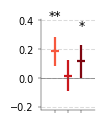

SA: r=-0.0457 [-0.1526, 0.0597], p=0.1829
CD: r=0.1323 [0.0410, 0.2185], p=0.0086
FC: r=0.0872 [-0.0085, 0.1829], p=0.0475


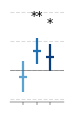

SA: r=0.1346 [0.0367, 0.2289], p=0.0086
CD: r=0.1009 [0.0038, 0.1956], p=0.0279
FC: r=0.1643 [0.0529, 0.2716], p=0.0026


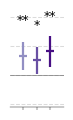

sa + cd: r=0.2101 [0.1198, 0.2959], p=0.0002
sa + fc: r=0.2094 [0.0977, 0.3153], p=0.0002
cd + fc: r=0.2077 [0.1002, 0.3097], p=0.0003
sa + cd +fc: r=0.2359 [0.1290, 0.3361], p=0.0003


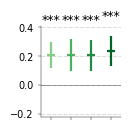

In [38]:
r_vals,r_lo,r_hi,r_p=recompile_r_vals_single_modality(sa_prediction_sig,dist_prediction_sig,fc_prediction_sig)

multimodal_ya=prep_best_of_df(hcp_data_sa,hcp_data_dist,hcp_data_fc)
multimodal_aged=prep_best_of_df(hcp_aged_data_sa,hcp_aged_data_dist,hcp_aged_data_fc)
multimodal_results,multimodal_predictions=test_multimodal_generalization(multimodal_ya,multimodal_aged)
lo=r_lo.min().min()
hi=multimodal_results['r_hi'].max()
### multiple ocmparinsons across single modalities 
pvals_mm=multimodal_results.iloc[3:,:]['r_p'].values

r_p=pd.DataFrame(multipletests(r_p.values.ravel(), method='fdr_tsbh')[1][0:9].reshape(3,3),index=r_p.index,columns=r_p.columns)

### multiple comparisons for combined modalities -- separate tests
pvals_mm=multipletests(multimodal_results.iloc[3:,:]['r_p'].values,method='fdr_tsbh')
mm_p_df=pd.DataFrame([pvals_mm[1]], index=['p'], columns=multimodal_results.index[-4:])
pointplot_ci(r_vals,'Positive',r_p,r_lo,r_hi,lo,hi,palette_pos,20,30,labelticks=True,opath=f'{odir}/reading_point_plot_pos_final')
pointplot_ci(r_vals,'Negative',r_p,r_lo,r_hi,lo,hi,palette_neg,20,30,labelticks=False,opath=f'{odir}/reading_point_plot_neg_final')
pointplot_ci(r_vals,'Joint',r_p,r_lo,r_hi,lo,hi,palette_jnt,20,30,labelticks=False,opath=f'{odir}/reading_point_plot_joint_final')


pointplot_ci_multimodal(multimodal_results.iloc[3:,:],multimodal_palette,lo,hi,mm_p_df,30,30,
                        opath=f'{odir}/reading_point_plot_multimodal_final',labelticks=True)

# Table S5 -- Distributional shift

How do the variables change across the young adult and aged cohorts?

In [53]:
multimodal_ya_all=prep_all_df(hcp_data_sa,hcp_data_dist,hcp_data_fc)
multimodal_a_all=prep_all_df(hcp_aged_data_sa,hcp_aged_data_dist,hcp_aged_data_fc)
df_train=multimodal_ya_all
df_test=multimodal_a_all

In [ ]:
for i in df_test.columns:
    d = pg.compute_effsize(df_train[i], df_test[i], eftype='cohen')
    print(i,d)

positive_sa -0.7662439377684133
negative_sa 0.12100302180300226
positive_cd -0.23750102955224348
negative_cd 0.029104948691974983
positive_fc 0.22627151008611995
negative_fc 0.42476292218892414
ReadEng_Unadj 0.5579571922791773
Age_L1 -3.3314423946712934
Age_L2 3.2942017268426533


In [ ]:
from scipy.stats import wasserstein_distance
for i in df_test.columns:
    d = wasserstein_distance(df_train[i], df_test[i])
    print(i,d)

positive_sa 0.47836396969241435
negative_sa 0.08756093309224977
positive_cd 0.12217643916256907
negative_cd 0.04335957908802513
positive_fc 0.262105856908454
negative_fc 0.41981342881457784
ReadEng_Unadj 0.5210897780511561
Age_L1 0.6534014847267859
Age_L2 0.645779375139409


# Generalization out of task 
Can an oral reading model predict word–association?

First make sure to load the picture vocabulary data. 

This can be accessed through the NIMH NDA.

In [ ]:
### DATA FROM HCP-A
pic_vocab=pd.read_csv('<lifepan hcp aging path>/tpvt01.txt',delimiter='\t').iloc[1:]
pic_vocab=pic_vocab[['src_subject_id','tpvt_uss',]]
pic_vocab.index=[int(i.strip('HCA')) for i in pic_vocab['src_subject_id']]
pic_vocab.drop(columns='src_subject_id',inplace=True)
pic_vocab=pic_vocab.astype(float)
pic_vocab=pd.DataFrame(pic_vocab['tpvt_uss']).dropna()

In [ ]:
## harmonization utility function. Not used in this instance but availabel for future
def harmonize_out_of_task(orig,new):
    """Utility function to norrmalize out of sample data. Not called in any analysis but available as an option"""
    std_old=np.std(orig)
    mean_old=np.mean(orig)
    mean_new=np.mean(new)
    std_new=np.std(new)

    zscored=(new-mean_new)/std_new
    return (zscored*std_old)+mean_old

def new_task_ds(train_ds, test_dataset, new_data,harmonize=False):
    updated_ds = deepcopy(test_dataset)
    
    # Align both datasets by index intersection
    combined = pd.concat([updated_ds.behaviorData, new_data], axis=1, join='inner')
    combined.dropna(inplace=True)

    print(f' correlation between measures{combined.corr().iloc[0,1]}')
    subs = combined.index
    tasks=combined.columns
    # Replace behavioral data with harmonized values
    if harmonize==True:
        harmonized_vals = harmonize_out_of_task(combined[tasks[0]].values,combined[tasks[1]].values)
    else:
        harmonized_vals=combined[tasks[1]].values

    updated_ds.behaviorData = updated_ds.behaviorData.loc[subs]
    updated_ds.brainData = updated_ds.brainData.loc[subs]
    updated_ds.confounds = updated_ds.confounds.loc[subs]
    updated_ds.indices = subs
    updated_ds.behaviorData['ReadEng_Unadj'] = harmonized_vals
    return updated_ds

Replace word recognition and pronunciation scores with word–picture association scores

The Correlation between pic vocab and reading is shown in cell output. 

Note, we only do this for aging. The idea is to use the trained reading model on pic vocab so we only ever touch this in the validation cohort.

In [ ]:
#### DISTANCE ####
## get the pic vocab dataset
pic_vocab_aging_dist=new_task_ds(hcp_edu_dist,hcp_edu_aged_dist,pic_vocab)

#### FUNCTIONAL CONNECTIVITY ####
## get the pic vocab dataset
pic_vocab_aging_fc=new_task_ds(hcp_edu_fc,hcp_edu_aged_fc,pic_vocab)

#### SURFACE AREA #### 
## get the pic vocab dataset
pic_vocab_aging_sa=new_task_ds(hcp_edu_sa,hcp_edu_aged_sa,pic_vocab)

 correlation between measures0.6468634394782383
 correlation between measures0.6468634394782383
 correlation between measures0.6468634394782383


In [62]:
### distance
hcp_data_dist,hcp_aged_data_dist=apply_transforms(hcp_edu_dist,pic_vocab_aging_dist,featsEdu_dist,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])
## predict
### fc 
hcp_data_fc,hcp_aged_data_fc=apply_transforms(hcp_edu_fc,pic_vocab_aging_fc,featsEdu_fc,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])

### sa
hcp_data_sa,hcp_aged_data_sa=apply_transforms(hcp_edu_sa,pic_vocab_aging_sa,featsEdu_sa,encode_cols=['Gender','Acquisition'],
                 passthrough_cols=['SSAGA_Educ','SSAGA_Income'],partial=['Age_L1','Age_L2'])

##3 predictions
dist_prediction_sig_pv,dist_preds_pv=test_prediction_generalization(hcp_data_dist,hcp_aged_data_dist,['Age_L1','Age_L2'],10_000)
fc_prediction_sig_pv,fc_preds_pv=test_prediction_generalization(hcp_data_fc,hcp_aged_data_fc,['Age_L1','Age_L2'],10_000)
sa_prediction_sig_pv,sa_preds_pv=test_prediction_generalization(hcp_data_sa,hcp_aged_data_sa,['Age_L1','Age_L2'],10_000)



adding acquisition dummy variable to test dataset
Cleaning all
['SSAGA_Educ', 'SSAGA_Income'] are being passed through as is
['Age_in_Yrs', 'Gender', 'Acquisition', 'SSAGA_Educ', 'SSAGA_Income', 'FS_IntraCranial_Vol', 'FS_BrainSeg_Vol', 'Larea', 'Rarea']
explained variance in head size by PCA
[0.9276304  0.05650164]
calculating partial correlation with respect to ['Age_L1', 'Age_L2']
residualizing both sides with Index(['Acquisition', 'Gender', 'BPSystolic', 'BPDiastolic', 'SSAGA_Income',
       'SSAGA_Educ', 'SizePC1', 'SizePC2'],
      dtype='object')
adding acquisition dummy variable to test dataset
Cleaning all
['SSAGA_Educ', 'SSAGA_Income'] are being passed through as is
['Age_in_Yrs', 'Gender', 'Acquisition', 'SSAGA_Educ', 'SSAGA_Income', 'FS_IntraCranial_Vol', 'FS_BrainSeg_Vol', 'Larea', 'Rarea']
explained variance in head size by PCA
[0.9276304  0.05650164]
calculating partial correlation with respect to ['Age_L1', 'Age_L2']
residualizing both sides with Index(['Acquisition', '

SA: r=0.1505 [0.0521, 0.2466], p=0.0100
CD: r=-0.0197 [-0.1207, 0.0830], p=0.4344
FC: r=0.1255 [0.0225, 0.2283], p=0.0167


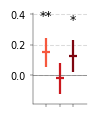

SA: r=-0.0045 [-0.1114, 0.1014], p=0.5144
CD: r=0.1053 [0.0028, 0.2041], p=0.0352
FC: r=0.0476 [-0.0439, 0.1369], p=0.2484


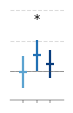

SA: r=0.1243 [0.0327, 0.2134], p=0.0167
CD: r=0.0636 [-0.0394, 0.1659], p=0.1754
FC: r=0.1460 [0.0441, 0.2429], p=0.0100


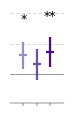

sa + cd: r=0.1679 [0.0682, 0.2622], p=0.0009
sa + fc: r=0.1808 [0.0811, 0.2787], p=0.0004
cd + fc: r=0.1786 [0.0754, 0.2757], p=0.0007
sa + cd +fc: r=0.2005 [0.0980, 0.2982], p=0.0004


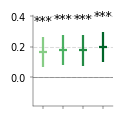

In [64]:
r_vals,r_lo,r_hi,r_p=recompile_r_vals_single_modality(sa_prediction_sig_pv,dist_prediction_sig_pv,fc_prediction_sig_pv)

### pic vocab
multimodal_ya=prep_best_of_df(hcp_data_sa,hcp_data_dist,hcp_data_fc)
multimodal_aged=prep_best_of_df(hcp_aged_data_sa,hcp_aged_data_dist,hcp_aged_data_fc)
multimodal_results_pic_vocab,multimodal_predictions_pic_vocab=test_multimodal_generalization(multimodal_ya,multimodal_aged)


lo=r_lo.min().min()
hi=multimodal_results['r_hi'].max()
### multiple ocmparinsons across single modalities 
pvals_mm=multimodal_results_pic_vocab.iloc[3:,:]['r_p'].values
r_p=pd.DataFrame(multipletests(r_p.values.ravel(), method='fdr_tsbh')[1][0:9].reshape(3,3),index=r_p.index,columns=r_p.columns)

### multiple comparisons for combined modalities -- separate tests
pvals_mm=multipletests(multimodal_results_pic_vocab.iloc[3:,:]['r_p'].values,method='fdr_tsbh')
mm_p_df=pd.DataFrame([pvals_mm[1]], index=['p'], columns=multimodal_results_pic_vocab.index[-4:])


pointplot_ci(r_vals,'Positive',r_p,r_lo,r_hi,lo,hi,palette_pos,20,30,labelticks=True,opath=f'{odir}/pic_vocab_point_plot_pos_final')
pointplot_ci(r_vals,'Negative',r_p,r_lo,r_hi,lo,hi,palette_neg,20,30,labelticks=False,opath=f'{odir}/pic_vocab_point_plot_neg_final')
pointplot_ci(r_vals,'Joint',r_p,r_lo,r_hi,lo,hi,palette_jnt,20,30,labelticks=False,opath=f'{odir}/pic_vocab_point_plot_joint_final')
pointplot_ci_multimodal(multimodal_results_pic_vocab.iloc[3:,:],multimodal_palette,lo,hi,mm_p_df,30,30,
                        opath=f'{odir}/pic_vocab_point_plot_multimodal_final',labelticks=True)